### **CC57 - MACHINE LEARNING - PREPROCESAMIENTO DE DATOS**

#### **Información del Conjunto de Datos**

**Origen:** https://www.kaggle.com/datasets/camnugent/california-housing-prices

**Descripción:**

Los datos pertenecen a las casas encontradas en un distrito determinado de California y algunas estadísticas resumidas sobre ellas basadas en los datos del censo de 1990.

El conjunto de datos contiene 20640 observaciones en 10 caracteristicas.

**Caracteristicas:**

1. longitude - longitud

2. latitude - latitud

3. housing_median_age - edad_mediana_vivienda

4. total_rooms - total_habitaciones

5. total_bedrooms - total_dormitorios

6. population - población

7. households - hogares

8. median_income - ingreso medio

9. median_house_value - valor_casa_mediana

10. ocean_proximity - proximidad_oceánica (cercana al mar)

#### **Transformación de datos:** Tecnica de Analisis de Componentes Principales (PCA)

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
import sys

if 'google.colab' in sys.modules:
    train = pd.read_csv(f'https://raw.githubusercontent.com/dReposU/ML/main/housing.csv')
else:
    train = pd.read_csv("housing.csv")
train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
train.shape

(20640, 10)

In [4]:
#Preprocesamiento express de los datos

# dropna():
#[de Pandas en Python se utiliza para limpiar conjuntos de datos eliminando filas o columnas que contienen valores
#faltantes (NaN, None). Elimina filas con al menos un valor nulo]
# Eliminamos los NA de los datos, que a sklearn no le gustan
train.dropna(inplace=True)

#DataFrame.drop():
#[method is used to remove specified rows or columns from a DataFrame]
# Eliminamos la variable ocean_proximity o bien la convertimos a 1 o 0 (cerca o no del mar)
train = train.drop('ocean_proximity', axis=1) # axis=1: se refiere a columnas

# Separamos nuestro target de los datos. Borramos la columna "median_house_value"
x = train.drop(columns='median_house_value')
target = train['median_house_value']

# Normalizamos las variables para que todas esten en la misma escala
x = StandardScaler().fit_transform(x)

In [5]:
#El dataset quedo asi
train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [6]:
#Luego de preprocesamiento
train.shape

(20433, 9)

In [7]:
#Nuestro arreglo numpy normalizado a partir de los datos del dataset en df

x

array([[-1.32731375,  1.05171726,  0.98216331, ..., -0.97331952,
        -0.97683327,  2.34516291],
       [-1.32232256,  1.04235526, -0.60621017, ...,  0.86133924,
         1.67037262,  2.33263161],
       [-1.33230494,  1.03767426,  1.85576873, ..., -0.81976943,
        -0.84342665,  1.78293943],
       ...,
       [-0.82320322,  1.77727236, -0.92388486, ..., -0.36882637,
        -0.17377773, -1.14317103],
       [-0.87311515,  1.77727236, -0.84446619, ..., -0.60356386,
        -0.39350628, -1.05513604],
       [-0.83318561,  1.74918635, -1.00330353, ..., -0.03348711,
         0.07995643, -0.78060586]], shape=(20433, 8))

El **PCA** (Principal Component Analysis) es una técnica de reducción de dimensionalidad no supervisada que transforma un gran conjunto de variables potencialmente correlacionadas en un conjunto más pequeño de variables no correlacionadas llamadas componentes principales, conservando la mayor parte de la información importante.

In [8]:
#Ejecutamos el PCA

# Creamos el objeto de PCA, indicando cuantos componentes queremos considerar
pca = PCA(n_components=2)
# Entrenamos el PCA con nuestros datos, y lo aplicamos a los datos
principalComponents = pca.fit_transform(x) #devuelve un Array
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2']) #Transformar el Array a DF
# Resultados
principalDf.head()

,principal component 1,principal component 2
0,-2.091848,1.395074
1,2.936717,1.934054
2,-1.968320,1.464482
3,-1.917650,1.505893
4,-1.775537,1.564319


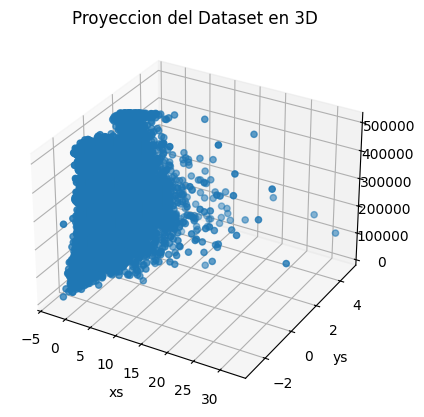

In [9]:
#Como ahora tenemos los datos en 3 dimensiones (2 variables y 1 target) ahora si que podemos ver de manera visual cómo
#están distribuidos nuestros datos

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') # The 111 argument means "1 row, 1 column, first subplot"
xs = principalDf.iloc[:,0] #Todas las filas de la primera columna, osea toda la columna 0
ys = principalDf.iloc[:,1] #Todas las filas de la segunda columna, osea toda la columna 1
zs = target

plt.xlabel('xs')
plt.ylabel('ys')

plt.title("Proyeccion del Dataset en 3D")
ax.scatter(xs=xs, ys=ys, zs=zs)

Como observamos que el target está muy concentrado, se debe posiblemente porque hemos reducido la cantidad de variables, y también porque hemos hecho un reescalado a los datos de entrenamiento.

Vamos a ver cómo se distribuyen los datos si nos quedáramos solo con un componente:

C:\Users\p\AppData\Local\Temp\ipykernel_7932\3382732087.py:13: RuntimeWarning: Second argument 'y' is ambiguous: could be a format string but is in 'data'; using as data.  If it was intended as data, set the format string to an empty string to suppress this warning.  If it was intended as a format string, explicitly pass the x-values as well.  Alternatively, rename the entry in 'data'.
  plt.plot( 'x', 'y', data=df, linestyle='none', marker='o')


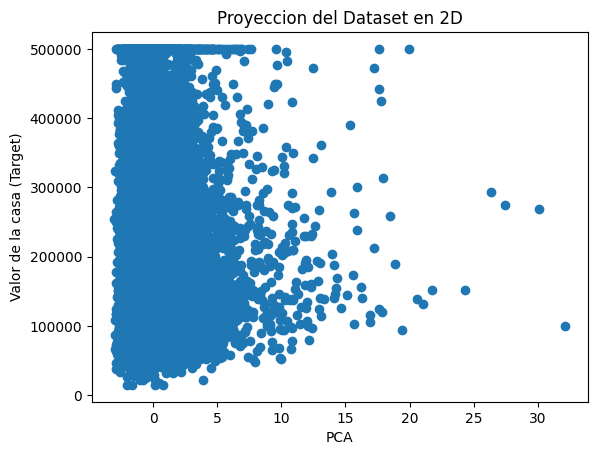

In [10]:
# Visualicemos ahora en una unica dimension
pca = PCA(n_components=1)
# Entrenamos el PCA con nuestros datos, y lo aplicamos a los datos
principalComponents = pca.fit_transform(x)
df = pd.DataFrame()
df['x'] = list(principalComponents) #unica variable x
df['y'] = target #variable y
# plot
plt.xlabel('PCA')
plt.ylabel('Valor de la casa (Target)')

plt.title("Proyeccion del Dataset en 2D")
plt.plot( 'x', 'y', data=df, linestyle='none', marker='o')
plt.show()

**Conclusiones**

- Incluir más datos (caracteristicas), por norma general, va a venir muy bien a nuestros modelos, pero es muy posible que aumenten la complejidad del modelo, o incluso incluyamos ruido e incrementemos el tiempo de calculo.
- **PCA** nos ayuda a mantener los componentes que más valor aportan, aunque tenemos que asumir que los datos son linealmente dependientes, y no siempre es así.
- Reducir los datos a dimensiones más pequeñas nos permite poder visualizar la distribución de nuestros datos